# BBox Mask Visualization

Notebook nay giup kiem tra GT bbox mask duoc tao tu label YOLO se trong nhu the nao tren anh goc.

In [2]:
!pip install torch

  Using cached torch-2.12.0-cp314-cp314-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached cuda_toolkit-13.0.2-py2.py3-none-any.whl.metadata (9.4 kB)
  Using cached nvidia_cublas-13.1.1.3-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached cuda_bindings-13.3.1-cp314-cp314-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.5 kB)
  Using cached nvidia_cudnn_cu13-9.20.0.48-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.1-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.29.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.wh

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display


# Ham nay tim repo root de notebook co the import code trong thu muc src.
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "docs").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from the current notebook working directory.")


REPO_ROOT = find_repo_root(Path.cwd()).resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.masks.bbox_mask import (
    create_bbox_mask_from_label_file,
    draw_box_outlines,
    label_path_from_image,
    load_yolo_boxes,
    mask_to_image,
    overlay_mask_on_image,
)
from src.xai.saliency_utils import get_split_image_dir, get_split_label_dir, list_image_files, load_yaml, resolve_path

plt.rcParams["figure.figsize"] = (18, 6)
plt.rcParams["axes.grid"] = False
print(f"Repo root: {REPO_ROOT}")

Repo root: /home/thanhmay/workspace/xai-driven-saliency-loss


In [4]:
DATASET_YAML = REPO_ROOT / "data" / "merged_yolo_grouped" / "dataset.yaml"
SPLIT = "val"   # chon: train, val, test
MAX_IMAGES = 8

assert DATASET_YAML.exists(), DATASET_YAML
print(DATASET_YAML)

/home/thanhmay/workspace/xai-driven-saliency-loss/data/merged_yolo_grouped/dataset.yaml


In [5]:
# Ham nay khoi tao duong dan image/label cho split dang xem.
def setup_mask_preview(dataset_yaml_path: Path, split: str) -> dict[str, Path]:
    dataset_yaml_path = resolve_path(dataset_yaml_path, base_dir=dataset_yaml_path.parent, repo_root=REPO_ROOT)
    dataset_config = load_yaml(dataset_yaml_path)
    image_dir = get_split_image_dir(dataset_config, dataset_yaml_path, split=split, repo_root=REPO_ROOT)
    label_dir = get_split_label_dir(image_dir)
    return {
        "dataset_yaml_path": dataset_yaml_path,
        "image_dir": image_dir,
        "label_dir": label_dir,
    }


# Ham nay tao ket qua preview cho mot anh gom image, bbox, mask va overlay.
def build_mask_preview(image_path: Path, label_dir: Path) -> dict:
    image = Image.open(image_path).convert("RGB")
    label_path = label_path_from_image(image_path, label_dir)
    boxes = load_yolo_boxes(label_path)
    mask = create_bbox_mask_from_label_file(label_path, image.size)
    boxed_image = draw_box_outlines(image, boxes, image.size)
    overlay_image = overlay_mask_on_image(image, mask)
    return {
        "image_path": image_path,
        "label_path": label_path,
        "image": image,
        "boxes": boxes,
        "mask": mask,
        "mask_image": mask_to_image(mask),
        "boxed_image": boxed_image,
        "overlay_image": overlay_image,
        "mask_area_pixels": int(mask.sum()),
        "mask_fill_ratio": float(mask.mean()) if mask.size else 0.0,
    }


# Ham nay hien thi anh goc, bbox, mask va overlay de danh gia chat luong mask.
def show_mask_preview(preview: dict) -> None:
    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    axes[0].imshow(preview["image"])
    axes[0].set_title("Original")
    axes[1].imshow(preview["boxed_image"])
    axes[1].set_title("BBox Outline")
    axes[2].imshow(preview["mask"], cmap="gray")
    axes[2].set_title("Binary Mask")
    axes[3].imshow(preview["overlay_image"])
    axes[3].set_title("Overlay")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame(
        [{
            "image": preview["image_path"].name,
            "label": preview["label_path"].name,
            "num_boxes": len(preview["boxes"]),
            "mask_area_pixels": preview["mask_area_pixels"],
            "mask_fill_ratio": preview["mask_fill_ratio"],
        }]
    )
    display(summary)
    if preview["boxes"]:
        display(pd.DataFrame(preview["boxes"]))


# Ham nay build preview cho nhieu anh de xem nhanh trong mot split.
def build_batch_preview(image_paths: list[Path], label_dir: Path) -> list[dict]:
    return [build_mask_preview(image_path, label_dir) for image_path in image_paths]


In [6]:
context = setup_mask_preview(DATASET_YAML, SPLIT)
image_paths = list_image_files(context["image_dir"])
display(pd.DataFrame({"image_path": [str(path) for path in image_paths[:MAX_IMAGES]]}))

,image_path
0,/home/thanhmay/workspace/xai-driven-saliency-l...
1,/home/thanhmay/workspace/xai-driven-saliency-l...
2,/home/thanhmay/workspace/xai-driven-saliency-l...
3,/home/thanhmay/workspace/xai-driven-saliency-l...
4,/home/thanhmay/workspace/xai-driven-saliency-l...
5,/home/thanhmay/workspace/xai-driven-saliency-l...
6,/home/thanhmay/workspace/xai-driven-saliency-l...
7,/home/thanhmay/workspace/xai-driven-saliency-l...


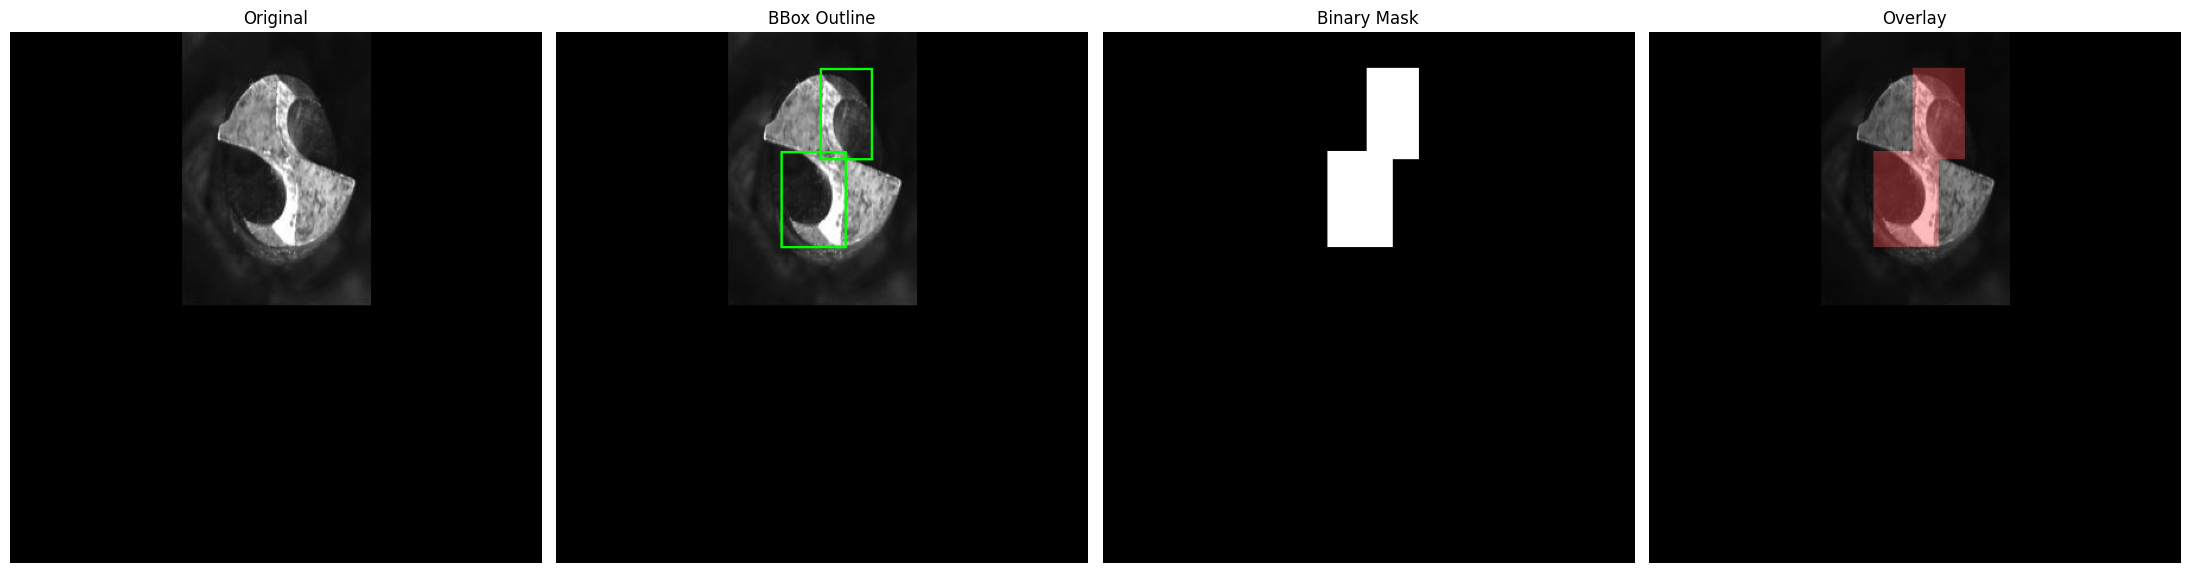

,image,label,num_boxes,mask_area_pixels,mask_fill_ratio
0,side__S100_Image__2025-09-10__11-46-17_bright_...,side__S100_Image__2025-09-10__11-46-17_bright_...,2,7689,0.03831


,class_id,x_center,y_center,width,height
0,5,0.544643,0.155134,0.098214,0.171875
1,5,0.483259,0.315848,0.122768,0.180804


In [7]:
sample_image_path = image_paths[0]
sample_preview = build_mask_preview(sample_image_path, context["label_dir"])
show_mask_preview(sample_preview)

In [8]:
batch_previews = build_batch_preview(image_paths[:MAX_IMAGES], context["label_dir"])
summary_df = pd.DataFrame(
    [
        {
            "image": preview["image_path"].name,
            "num_boxes": len(preview["boxes"]),
            "mask_area_pixels": preview["mask_area_pixels"],
            "mask_fill_ratio": preview["mask_fill_ratio"],
        }
        for preview in batch_previews
    ]
)
display(summary_df)

,image,num_boxes,mask_area_pixels,mask_fill_ratio
0,side__S100_Image__2025-09-10__11-46-17_bright_...,2,7689,0.038310
1,side__S101_Image__2025-09-10__12-16-33_dark_2_...,2,7855,0.039137
2,side__S110_Image__2025-09-22__14-25-02_dark_1_...,2,11224,0.055923
3,side__S111_Image__2025-09-22__14-52-58_bright_...,1,4623,0.023034
4,side__S111_Image__2025-09-22__14-52-58_bright_...,1,4736,0.023597
5,side__S111_Image__2025-09-22__14-52-58_bright_...,2,8784,0.043766
6,side__S111_Image__2025-09-22__14-52-58_bright_...,2,9624,0.047951
7,side__S111_Image__2025-09-22__14-52-58_bright_...,1,1827,0.009103


side__S100_Image__2025-09-10__11-46-17_bright_1_crop_9.jpg


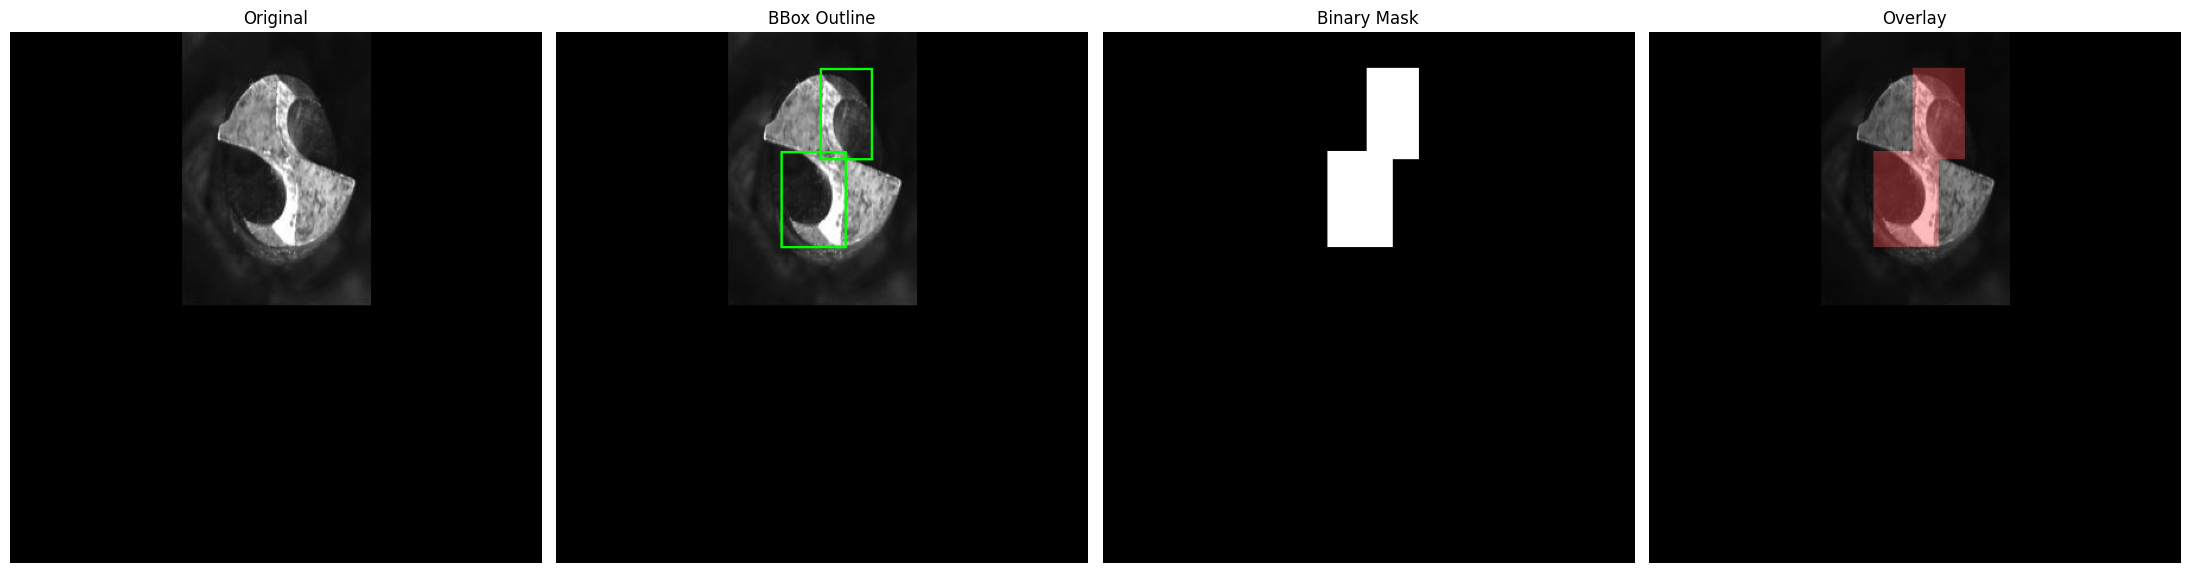

,image,label,num_boxes,mask_area_pixels,mask_fill_ratio
0,side__S100_Image__2025-09-10__11-46-17_bright_...,side__S100_Image__2025-09-10__11-46-17_bright_...,2,7689,0.03831


,class_id,x_center,y_center,width,height
0,5,0.544643,0.155134,0.098214,0.171875
1,5,0.483259,0.315848,0.122768,0.180804


side__S101_Image__2025-09-10__12-16-33_dark_2_crop_4_jpg.jpg


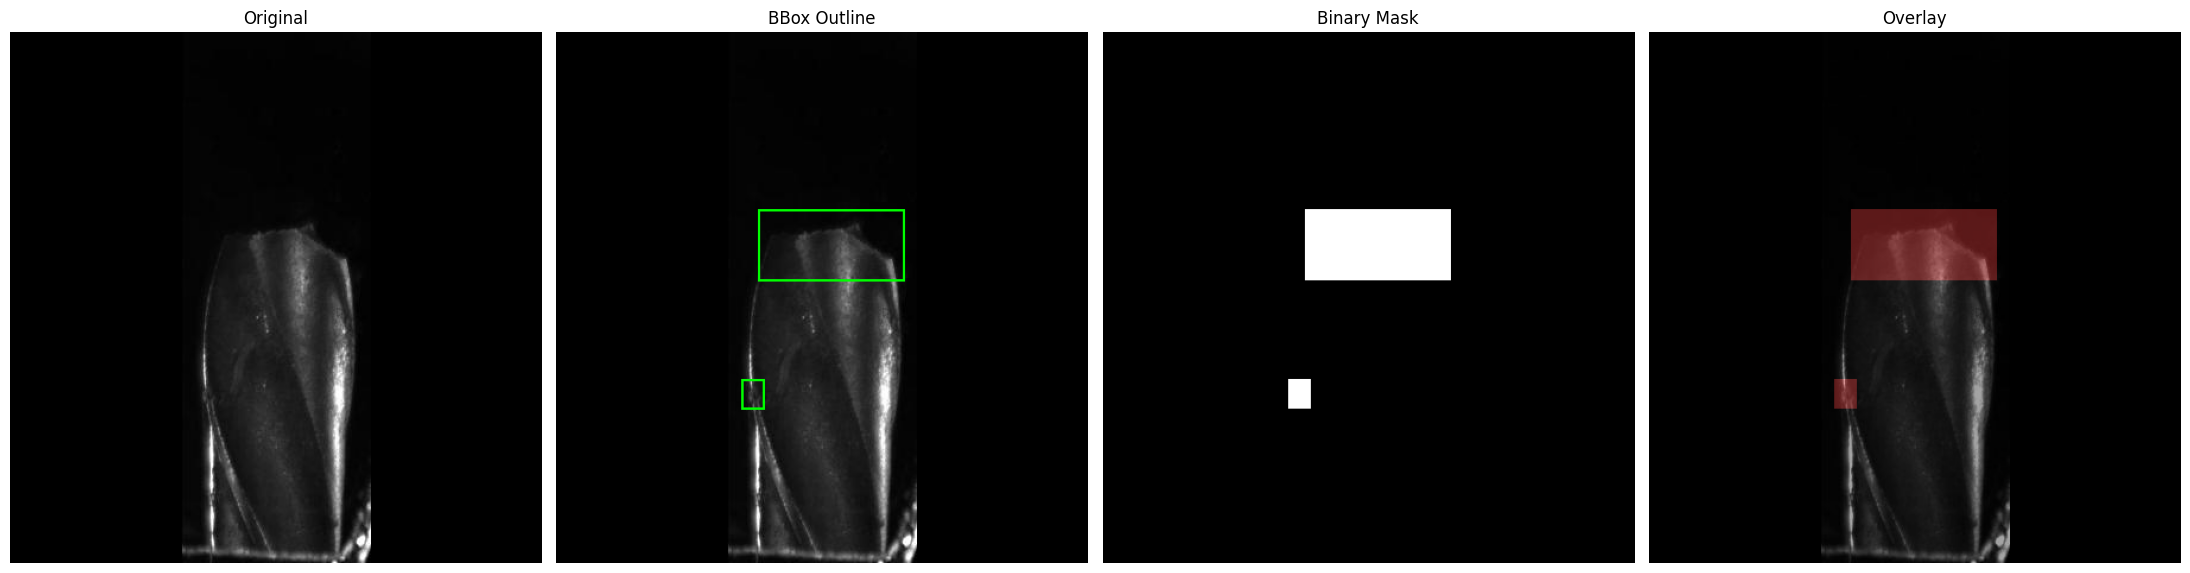

,image,label,num_boxes,mask_area_pixels,mask_fill_ratio
0,side__S101_Image__2025-09-10__12-16-33_dark_2_...,side__S101_Image__2025-09-10__12-16-33_dark_2_...,2,7855,0.039137


,class_id,x_center,y_center,width,height
0,1,0.516741,0.401786,0.274554,0.133929
1,2,0.369420,0.681920,0.042411,0.055804


side__S110_Image__2025-09-22__14-25-02_dark_1_crop_9.jpg


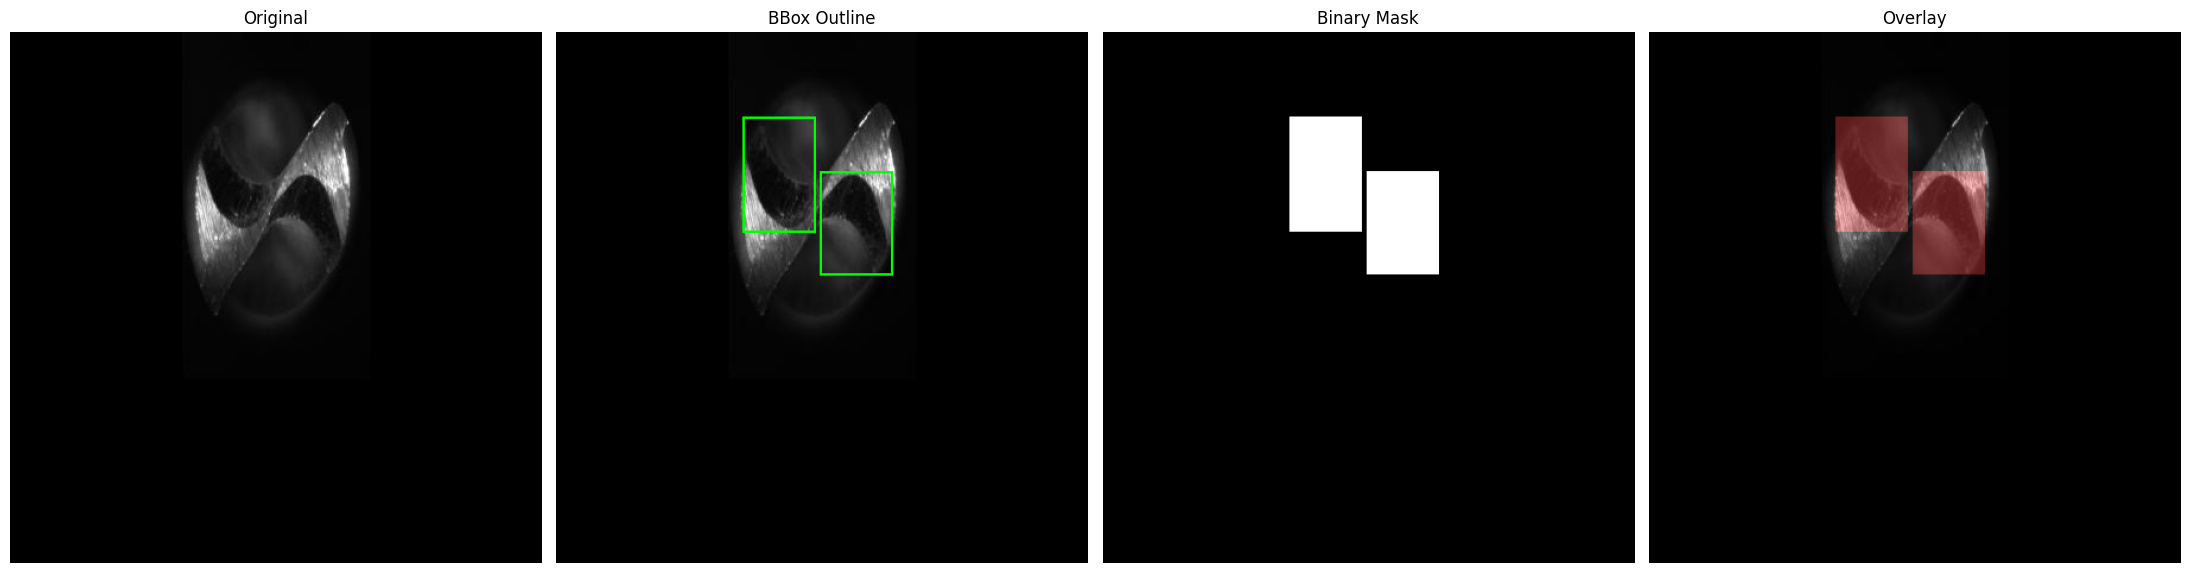

,image,label,num_boxes,mask_area_pixels,mask_fill_ratio
0,side__S110_Image__2025-09-22__14-25-02_dark_1_...,side__S110_Image__2025-09-22__14-25-02_dark_1_...,2,11224,0.055923


,class_id,x_center,y_center,width,height
0,5,0.418527,0.268973,0.136161,0.216518
1,5,0.563616,0.360491,0.136161,0.194196


In [9]:
# Hien thi nhanh 3 anh dau tien de xem mask trong nhieu truong hop.
for preview in batch_previews[:3]:
    print(preview["image_path"].name)
    show_mask_preview(preview)